In [43]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

In [174]:
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# 1. BUSINESS UNDERSTANDING
## **Tujuan bisnis:**
Tim marketing ingin memahami kelompok-kelompok pelanggan yang ada berdasarkan usia, pendapatan tahunan, dan skor belanja, agar bisa merancang strategi promosi/produk yang lebih tepat sasaran untuk tiap kelompok (bukan strategi "satu untuk semua pelanggan").

## **Pertanyaan bisnis yang ingin dijawab:**
* Ada berapa kelompok (segmen) pelanggan yang berbeda karakteristik?
* Apa ciri khas tiap segmen (usia, pendapatan, pola belanja)?
* Strategi marketing apa yang cocok untuk tiap segmen?

## **Tujuan data mining (data mining goal):**
Mengelompokkan (clustering) pelanggan ke dalam beberapa segmen menggunakan algoritma K-Means, berdasarkan atribut numerik yang tersedia (Usia, Pendapatan_Tahunan_Juta, Skor_Belanja).

# 2. DATA UNDERSTANDING
Mengumpulkan data, mendeskripsikan data, dan mengeksplorasi data untuk mengenali kualitas data (missing value, duplikasi, anomali) sebelum diproses lebih lanjut.

Mengumpulkan data (Collect Initial Data). Ambil data dari .csv

In [48]:
df = pd.read_csv('ecommerce_data.csv', encoding='ISO-8859-1', sep=';', on_bad_lines='skip')
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
None
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE W

Melihat tipe data/struktur data

In [49]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
None


Melihat contoh 5 baris pertama dari data tersebut

In [50]:
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  12/01/2010 08:26       2.55     17850.0  United Kingdom  
1  12/01/2010 08:26       3.39     17850.0  United Kingdom  
2  12/01/2010 08:26       2.75     17850.0  United Kingdom  
3  12/01/2010 08:26       3.39     17850.0  United Kingdom  
4  12/01/2010 08:26       3.39     17850.0  United Kingdom  


Melihat statistik deskriptif kolom numerik

In [51]:
print(df.describe())

            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000


Melihat data yang memiliki missing value

In [52]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


Melihat baris data yang memiliki duplikasi (Identik penuk)

In [53]:
print(df.duplicated().sum())

5268


Cek inkonsistensi penulisan, disini berdasarkan data yang sudah kita lihat berdasarkan `df.head()`

In [55]:
# Cek sebaran transaksi berdasarkan negara asal pembeli
print(df['Country'].value_counts(dropna=False).head(10))

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64


# 3. DATA PREPARATION
Membersihkan dan menyiapkan data agar siap dipakai untuk modeling. Termasuk: pembersihan data (cleaning), transformasi (scaling), dan pemilihan atribut (feature selection) yang akan dipakai model.

Hapus baris yang tidak memiliki CustomerID

In [56]:
df_clean = df.dropna(subset=['CustomerID']).copy()

Hapus transaksi retur/batal dan kuantitas bernilai non-positif

In [57]:
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C', na=False)]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

Hitung total nilai belanja per transaksi

In [58]:
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [59]:
print("Jumlah transaksi bersih dan valid:", len(df_clean))

Jumlah transaksi bersih dan valid: 397884


In [60]:
import datetime as dt

Tentukan tanggal referensi (1 hari setelah transaksi paling terakhir)

In [61]:
ref_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

Agregasi per pelanggan

In [62]:
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                              # Frequency
    'TotalPrice': 'sum'                                  # Monetary
}).reset_index()

In [63]:
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [64]:
print("Jumlah Pelanggan Unik:", len(rfm))
print("\n5 Data Teratas RFM:")
print(rfm.head())

Jumlah Pelanggan Unik: 4338

5 Data Teratas RFM:
   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40


Visualisasi Boxplot data bersih

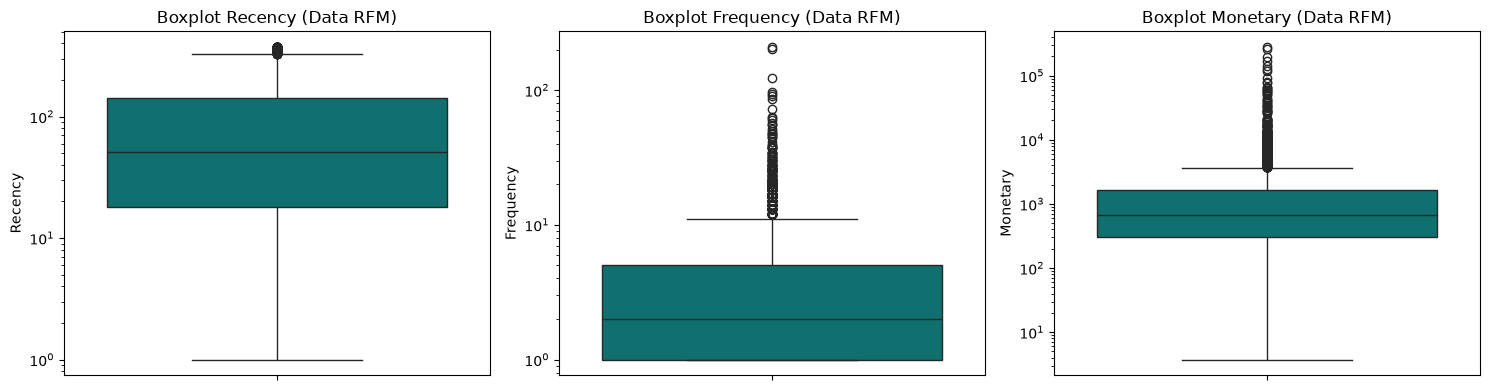

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
kolom_rfm = ['Recency', 'Frequency', 'Monetary']

for ax, kol in zip(axes, kolom_rfm):
    sns.boxplot(y=rfm[kol], ax=ax, color='teal')
    ax.set_title(f'Boxplot {kol} (Data RFM)')
    ax.set_yscale('log')  # Menggunakan skala log agar nilai ekstrem tetap rapi terlihat

plt.tight_layout()
plt.show()

# Transformasi Log & Feature Scaling

Transformasi Logaritmik untuk meredam skewness ekstrem

In [66]:
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])

Standarisasi Fitur

In [67]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_log)

Ubah ke DataFrame untuk pengecekan

In [68]:
X_scaled_df = pd.DataFrame(X_scaled, columns=['Recency', 'Frequency', 'Monetary'])
print("Data RFM setelah Log Transformation & StandardScaler:")
print(X_scaled_df.head())

Data RFM setelah Log Transformation & StandardScaler:
    Recency  Frequency  Monetary
0  1.461993  -0.955214  3.706225
1 -2.038734   1.074425  1.411843
2  0.373104   0.386304  0.716489
3 -0.623086  -0.955214  0.698739
4  1.424558  -0.955214 -0.618962


# 4. MODELING
Memilih teknik modeling, menentukan parameter (jumlah cluster), dan membangun model K-Means.

Menentukan $k$ Optimal (Elbow Method & Silhouette)Menguji beberapa kali nilai K dengan Elbow Method

In [69]:
inertia_list = []
silhouette_list = []
rentang_k = range(2, 9)

In [70]:
for k in rentang_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, labels))
    print(f"k={k} -> Inertia: {km.inertia_:.2f} | Silhouette: {silhouette_list[-1]:.3f}")

k=2 -> Inertia: 6481.23 | Silhouette: 0.433
k=3 -> Inertia: 4867.85 | Silhouette: 0.337
k=4 -> Inertia: 3938.51 | Silhouette: 0.337
k=5 -> Inertia: 3295.98 | Silhouette: 0.316
k=6 -> Inertia: 2855.01 | Silhouette: 0.313
k=7 -> Inertia: 2548.91 | Silhouette: 0.310
k=8 -> Inertia: 2336.78 | Silhouette: 0.301


Plot Elbow Method

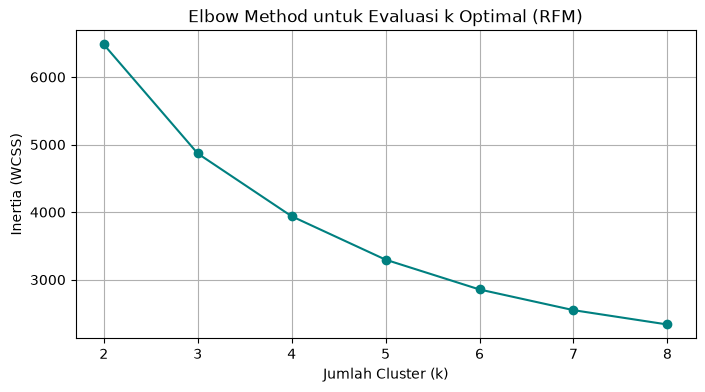

In [71]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(list(rentang_k), inertia_list, marker='o', color='teal')
ax1.set_title('Elbow Method untuk Evaluasi k Optimal (RFM)')
ax1.set_xlabel('Jumlah Cluster (k)')
ax1.set_ylabel('Inertia (WCSS)')
plt.grid(True)
plt.show()

Pelatihan Model K-Means Final ($k = 4$)

In [72]:
k_optimal = 4
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(X_scaled)

print("Distribusi jumlah pelanggan per cluster:")
print(rfm['Cluster'].value_counts().sort_index())

Distribusi jumlah pelanggan per cluster:
Cluster
0     837
1     716
2    1173
3    1612
Name: count, dtype: int64


Visualisasi Hasil Clustering

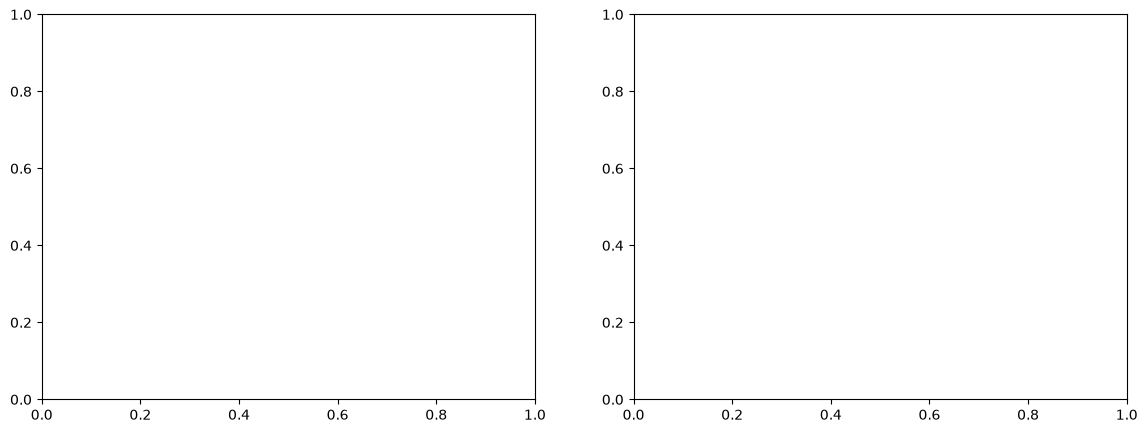

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

Recency vs Monetary

In [74]:
sns.scatterplot(
    data=rfm, x='Recency', y='Monetary', hue='Cluster',
    palette='Set2', s=50, ax=axes[0]
)
axes[0].set_yscale('log')
axes[0].set_title('Cluster: Recency vs Monetary (Skala Log)')

Text(0.5, 1.0, 'Cluster: Recency vs Monetary (Skala Log)')

Frequency vs Monetary

In [75]:
sns.scatterplot(
    data=rfm, x='Frequency', y='Monetary', hue='Cluster',
    palette='Set2', s=50, ax=axes[1]
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Cluster: Frequency vs Monetary (Skala Log)')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

# Profiling Bisnis & Simpan Model

Menghitung nilai rata-rata tiap metrik RFM per cluster

In [76]:
profil_rfm = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).round(1).rename(columns={'CustomerID': 'Jumlah_Anggota'})

print("[Deployment] Ringkasan Profil Cluster:")
print(profil_rfm)

[Deployment] Ringkasan Profil Cluster:
         Recency  Frequency  Monetary  Jumlah_Anggota
Cluster                                              
0           18.1        2.1     551.8             837
1           12.1       13.7    8074.3             716
2           71.1        4.1    1802.8            1173
3          182.5        1.3     343.5            1612


# 5. EVALUASI
Evaluasi Metrik Teknis (Silhouette Score & Inertia)

In [78]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

Silhouette Score (Mengukur seberapa mirip titik data ke clusternya sendiri dibanding cluster lain)

In [79]:
sil_score = silhouette_score(X_scaled, rfm['Cluster'])

Davies-Bouldin Index (Semakin kecil nilainya, semakin baik pemisahan clusternya)

In [80]:
db_score = davies_bouldin_score(X_scaled, rfm['Cluster'])

In [81]:
print(f"=== EVALUASI TEKNIS MODEL (k={k_optimal}) ===")
print(f"Silhouette Score      : {sil_score:.3f}")
print(f"Davies-Bouldin Index  : {db_score:.3f}")

=== EVALUASI TEKNIS MODEL (k=4) ===
Silhouette Score      : 0.337
Davies-Bouldin Index  : 1.010


# Evaluasi Validasi Bisnis (Apakah Cluster Masuk Akal?)

Cek median atau nilai minimum & maksimum tiap cluster untuk memastikan pemisahan

In [82]:
eval_ringkasan = rfm.groupby('Cluster').agg({
    'Recency': ['min', 'median', 'max'],
    'Frequency': ['min', 'median', 'max'],
    'Monetary': ['min', 'median', 'max'],
    'CustomerID': 'count'
}).round(1)

In [83]:
print(eval_ringkasan)

        Recency             Frequency             Monetary                    \
            min median  max       min median  max      min  median       max   
Cluster                                                                        
0             1   17.0   53         1    2.0    7     35.4   471.7    3861.0   
1             1    8.0  372         2   10.0  209    808.6  3733.9  280206.0   
2             8   56.0  366         1    4.0   14    322.4  1345.6   77183.6   
3            23  177.0  374         1    1.0    6      3.8   298.3    2169.4   

        CustomerID  
             count  
Cluster             
0              837  
1              716  
2             1173  
3             1612  


# Visualisasi Silhouette Analysis (Evaluasi Matematis)
Visualisasi ini mengukur ketebalan dan kohesi tiap cluster. Garis putus-putus merah adalah rata-rata skor siluet keseluruhan.

In [84]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

Hitung nilai silhouette tiap sampel data

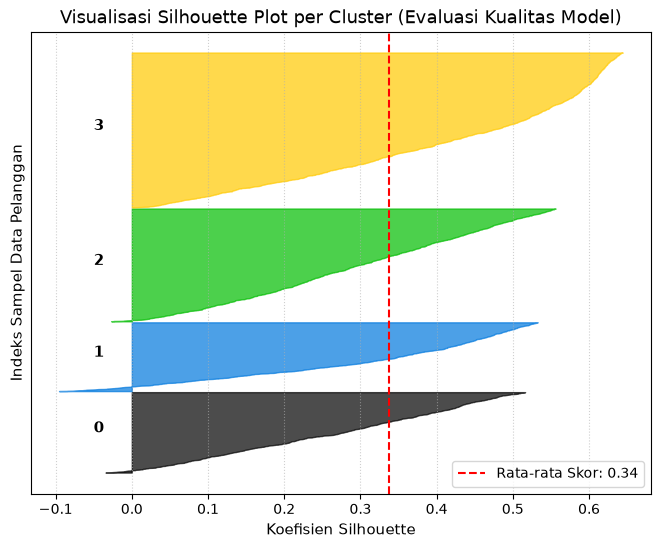

In [86]:
silhouette_vals = silhouette_samples(X_scaled, rfm['Cluster'])
avg_score = silhouette_score(X_scaled, rfm['Cluster'])

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10

for i in range(k_optimal):
    # Ambil nilai silhouette untuk cluster ke-i dan urutkan
    ith_cluster_vals = silhouette_vals[rfm['Cluster'] == i]
    ith_cluster_vals.sort()
    
    size_cluster_i = ith_cluster_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = cm.nipy_spectral(float(i) / k_optimal)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_vals,
                    facecolor=color, edgecolor=color, alpha=0.7)
    
    # Beri label nomor cluster di samping grafik
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=11, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=avg_score, color="red", linestyle="--", label=f'Rata-rata Skor: {avg_score:.2f}')
ax.set_title("Visualisasi Silhouette Plot per Cluster (Evaluasi Kualitas Model)", fontsize=13)
ax.set_xlabel("Koefisien Silhouette", fontsize=11)
ax.set_ylabel("Indeks Sampel Data Pelanggan", fontsize=11)
ax.set_yticks([])  # Hilangkan angka sumbu y agar rapi
ax.legend(loc='lower right')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()

# Snake Plot / Profil Relatif RFM (Evaluasi Bisnis)
Snake plot menormalkan ketiga fitur ke skala standar (standardized values) agar kita bisa melihat garis tren perilaku tiap segmen secara berdampingan.

Siapkan DataFrame bernilai scaled yang sudah berlabel cluster

In [87]:
df_snake = pd.DataFrame(X_scaled, columns=['Recency', 'Frequency', 'Monetary'])
df_snake['Cluster'] = rfm['Cluster']

Ubah bentuk data menjadi format panjang (melt) untuk visualisasi perbandingan

In [88]:
df_snake_melted = pd.melt(
    df_snake.reset_index(),
    id_vars=['Cluster'],
    value_vars=['Recency', 'Frequency', 'Monetary'],
    var_name='Metrik_RFM',
    value_name='Nilai_Terkorelasi_ZScore'
)

Plot diagram snake

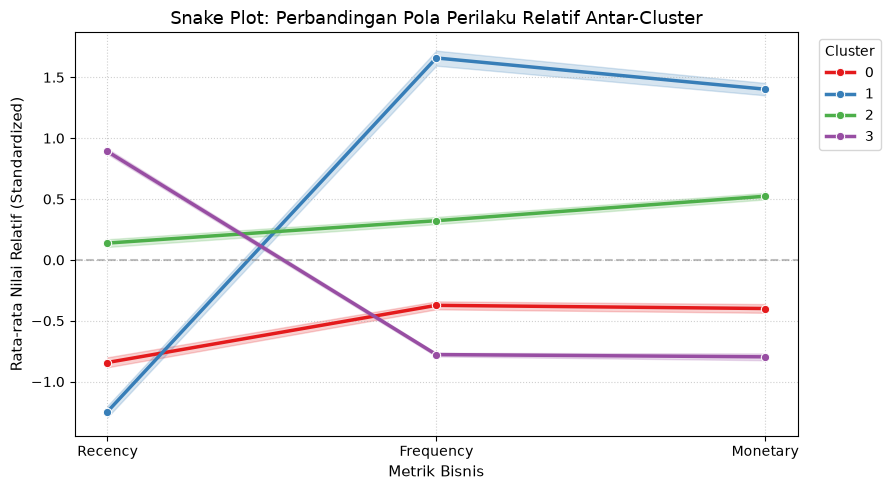

In [89]:
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=df_snake_melted,
    x='Metrik_RFM',
    y='Nilai_Terkorelasi_ZScore',
    hue='Cluster',
    palette='Set1',
    marker='o',
    linewidth=2.5
)

plt.title("Snake Plot: Perbandingan Pola Perilaku Relatif Antar-Cluster", fontsize=13)
plt.xlabel("Metrik Bisnis", fontsize=11)
plt.ylabel("Rata-rata Nilai Relatif (Standardized)", fontsize=11)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [91]:
fitur = ['Recency', 'Frequency', 'Monetary']

profil_cluster = rfm.groupby('Cluster')[fitur].mean().round(1)
profil_cluster['Jumlah_Anggota'] = rfm['Cluster'].value_counts().sort_index()

print("\n[Evaluasi Bisnis] Profil rata-rata tiap cluster:")
print(profil_cluster)


[Evaluasi Bisnis] Profil rata-rata tiap cluster:
         Recency  Frequency  Monetary  Jumlah_Anggota
Cluster                                              
0           18.1        2.1     551.8             837
1           12.1       13.7    8074.3             716
2           71.1        4.1    1802.8            1173
3          182.5        1.3     343.5            1612


# 6. Deployment
Menyajikan hasil dalam bentuk yang bisa dipakai oleh pengguna bisnis (misal tim marketing), termasuk rekomendasi tindakan per segmen, serta menyimpan data & model untuk dipakai ulang.

Hitung rata-rata nilai metrik RFM per cluster

In [92]:
fitur = ['Recency', 'Frequency', 'Monetary']
profil_cluster = rfm.groupby('Cluster')[fitur].mean().round(1)
profil_cluster['Jumlah_Anggota'] = rfm['Cluster'].value_counts().sort_index()

Fungsi penamaan segmen bisnis berdasarkan profil metrik RFM

In [93]:
def beri_nama_segmen_rfm(row):
    rec = row['Recency']
    freq = row['Frequency']
    mon = row['Monetary']
    
    # Pelanggan yang baru saja belanja, frekuensi sering, dan uang belanja besar
    if rec <= 40 and freq >= 5 and mon >= 1500:
        return 'Champions / Sultan (Sangat Aktif & Loyal)'
    # Pelanggan yang aktif dan cukup rutin belanja
    elif rec <= 60 and freq >= 3:
        return 'Loyal Customers (Pelanggan Rutin)'
    # Pelanggan yang frekuensinya lumayan tapi sudah lama tidak kembali
    elif rec > 90 and freq >= 3:
        return 'At Risk (Berisiko Churn / Butuh Retensi)'
    # Pelanggan yang transaksi sedikit, belanja kecil, atau sudah lama tidak aktif
    else:
        return 'Hibernating / Lost (Pasif atau Baru Belanja Sekali)'

Beri label nama segmen ke tabel profil dan data pelanggan

In [94]:
profil_cluster['Nama_Segmen'] = profil_cluster.apply(beri_nama_segmen_rfm, axis=1)
mapping_nama = profil_cluster['Nama_Segmen'].to_dict()
rfm['Nama_Segmen'] = rfm['Cluster'].map(mapping_nama)

print("\n[Deployment] Profil Bisnis Tiap Cluster:")
print(profil_cluster[['Jumlah_Anggota', 'Recency', 'Frequency', 'Monetary', 'Nama_Segmen']])


[Deployment] Profil Bisnis Tiap Cluster:
         Jumlah_Anggota  Recency  Frequency  Monetary  \
Cluster                                                 
0                   837     18.1        2.1     551.8   
1                   716     12.1       13.7    8074.3   
2                  1173     71.1        4.1    1802.8   
3                  1612    182.5        1.3     343.5   

                                               Nama_Segmen  
Cluster                                                     
0        Hibernating / Lost (Pasif atau Baru Belanja Se...  
1                Champions / Sultan (Sangat Aktif & Loyal)  
2        Hibernating / Lost (Pasif atau Baru Belanja Se...  
3        Hibernating / Lost (Pasif atau Baru Belanja Se...  


Pemetaan nama segmen bisnis berdasarkan profil metrik nyata cluster

In [96]:
mapping_nama = {
    1: 'Champions / Sultan (Sangat Aktif & Belanja Besar)',
    2: 'Loyal Customers (Pelanggan Rutin & Potensial)',
    0: 'Promising / New Customers (Pelanggan Baru/Tumbuh)',
    3: 'Lost / Hibernating (Pasif & Sudah Lama Tidak Belanja)'
}

profil_cluster['Nama_Segmen'] = profil_cluster.index.map(mapping_nama)
rfm['Nama_Segmen'] = rfm['Cluster'].map(mapping_nama)

print("\n[Deployment] Profil Lengkap Tiap Cluster:")
print(profil_cluster[['Jumlah_Anggota', 'Recency', 'Frequency', 'Monetary', 'Nama_Segmen']])


[Deployment] Profil Lengkap Tiap Cluster:
         Jumlah_Anggota  Recency  Frequency  Monetary  \
Cluster                                                 
0                   837     18.1        2.1     551.8   
1                   716     12.1       13.7    8074.3   
2                  1173     71.1        4.1    1802.8   
3                  1612    182.5        1.3     343.5   

                                               Nama_Segmen  
Cluster                                                     
0        Promising / New Customers (Pelanggan Baru/Tumbuh)  
1        Champions / Sultan (Sangat Aktif & Belanja Besar)  
2            Loyal Customers (Pelanggan Rutin & Potensial)  
3        Lost / Hibernating (Pasif & Sudah Lama Tidak B...  


In [97]:
rekomendasi = {
    'Champions / Sultan (Sangat Aktif & Belanja Besar)': 
        'Berikan perlakuan VIP, akses eksklusif produk baru, dan reward loyalitas tanpa potongan diskon.',
    
    'Loyal Customers (Pelanggan Rutin & Potensial)': 
        'Tawarkan bundling produk, diskon bersyarat (misal: belanja min. $1000), dan rekomendasi produk terkait (upselling).',
    
    'Promising / New Customers (Pelanggan Baru/Tumbuh)': 
        'Kirimkan voucher diskon untuk order kedua dan newsletter katalog produk terlaris agar terdorong belanja ulang.',
    
    'Lost / Hibernating (Pasif & Sudah Lama Tidak Belanja)': 
        'Kirimkan kampanye email win-back "We Miss You" disertai kupon diskon berbatas waktu (FOMO) untuk reaktivasi.'
}

print("\n[Deployment] Rekomendasi Strategi Marketing per Segmen:")
for segmen, saran in rekomendasi.items():
    print(f"\n📌 {segmen}:\n   👉 {saran}")


[Deployment] Rekomendasi Strategi Marketing per Segmen:

📌 Champions / Sultan (Sangat Aktif & Belanja Besar):
   👉 Berikan perlakuan VIP, akses eksklusif produk baru, dan reward loyalitas tanpa potongan diskon.

📌 Loyal Customers (Pelanggan Rutin & Potensial):
   👉 Tawarkan bundling produk, diskon bersyarat (misal: belanja min. $1000), dan rekomendasi produk terkait (upselling).

📌 Promising / New Customers (Pelanggan Baru/Tumbuh):
   👉 Kirimkan voucher diskon untuk order kedua dan newsletter katalog produk terlaris agar terdorong belanja ulang.

📌 Lost / Hibernating (Pasif & Sudah Lama Tidak Belanja):
   👉 Kirimkan kampanye email win-back "We Miss You" disertai kupon diskon berbatas waktu (FOMO) untuk reaktivasi.


Simpan Model & Data Hasil Segmentasi (di Notebook)

In [98]:
import joblib

# 1. Simpan Model K-Means dan Scaler
joblib.dump(kmeans_final, 'model_kmeans_rfm.pkl')
joblib.dump(scaler, 'scaler_rfm.pkl')

# 2. Ekspor hasil segmentasi pelanggan ke file CSV
rfm.to_csv('hasil_segmentasi_pelanggan_rfm.csv', index=False)

print("Semua file deployment (.pkl dan .csv) berhasil disimpan!")

Semua file deployment (.pkl dan .csv) berhasil disimpan!
